
# PIER vs ICE / PDP / SHAP（同一路径对照）

本 Notebook 复现论文中“**同伴相对解释（PIER/DISCO）** 与 **单模型解释（ICE/PDP/SHAP）** 的对照”，
保证**同一干预 $T_d$、同一后置剂量网格 $\Theta$**（与预网格 $\Theta_0$ 不重叠，满足“诚实/防泄漏”拆分）。
PIER 的定义与“预/后网格拆分”的必要性见论文 §3–§3.2；算法见 Algorithm 1。

> 运行环境：本 Notebook **尽量复用仓库已有代码**（设备 `device`、干预 `T_d`、PIER 曲线计算）。
> 当某些模块路径差异导致导入失败时，Notebook 内提供了**最小兜底实现**（不改仓库源码）。



**注意**：为了符合论文中的“诚实/防泄漏（honesty/no‑leakage）”——预网格仅用于同伴投影的拟合，
后网格仅用于评估——我们在本 Notebook 中**强制**：ICE/PDP/SHAP 与 PIER **共用同一后网格**，
且与预网格不重叠。详见论文 §3.2 与 Algorithm 1 的第 5–9 步。

In [1]:

# 如果环境中未装 shap，请先取消注释下一行安装
# !pip install shap -q

import numpy as np
import matplotlib.pyplot as plt

# 为了与仓库风格一致，不设置 matplotlib 风格，也不引入 seaborn
plt.rcParams['figure.dpi'] = 120


In [2]:

def ensure_2d(x):
    x = np.asarray(x)
    return x[None, :] if x.ndim == 1 else x

def predict_scalar(predict_fn, X, g=None):
    raw = predict_fn(X)
    return (g(raw) if g is not None else raw).reshape(-1)

def apply_Td(X, theta, T_d):
    """优先用对象的 .apply(X, theta)；否则把 T_d 当作可调用。"""
    if hasattr(T_d, "apply"):
        return T_d.apply(X, theta)
    return T_d(X, theta)



## 设备与数据（参照 `te_auc_synthetic.ipynb` 的做法）

这一节与 `te_auc_synthetic.ipynb` 保持一致：
1. 用**合成生成器**采样数据，训练一套**异构模型**作为生态（目标 + 同伴）。
2. 用仓库里的 **Device 适配器**（如 `SklearnTabularDevice`）把模型统一成 `predict`/`predict_raw` 接口。
3. 构造**公开探针集** `probes_X`（只用于预网格响应与匹配）。
4. 定义**干预** `T_d` 与**预/后网格**（后网格只用于评估）。


In [3]:

# —— 3.1 生成数据，与 te_auc_synthetic 的 synthetic 设置一致 ——
# 这里用 sklearn 的合成数据作为“生成器”近似；若仓库内有更具体的生成器，请替换为相应导入。
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X, y = make_regression(n_samples=8000, n_features=16, n_informative=8, noise=10.0, random_state=7)
X_tr, X_rest, y_tr, y_rest = train_test_split(X, y, test_size=0.4, random_state=7)
X_val, X_te, y_val, y_te = train_test_split(X_rest, y_rest, test_size=0.5, random_state=7)

# —— 3.2 训练“生态系统”里的模型（目标 + 多个同伴） ——
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

est_target = GradientBoostingRegressor(random_state=0).fit(X_tr, y_tr)
est_peer1  = RandomForestRegressor(n_estimators=200, random_state=0).fit(X_tr, y_tr)
est_peer2  = Ridge(alpha=1.0).fit(X_tr, y_tr)
est_peer3  = GradientBoostingRegressor(random_state=13).fit(X_tr, y_tr)

# —— 3.3 参照 te_auc_synthetic：将 sklearn 模型封装为仓库的 Device ——
# 如果仓库内提供了 SklearnTabularDevice，则直接用；否则做一个极简兜底包装。
try:
    from disco.devices.sklearn_tabular import SklearnTabularDevice  # 你们仓库已有
    def make_device(est, name):
        # 回归任务，标量化 g 取 identity；分类时可用 prob 或 logit，与你们 PIER 一致
        return SklearnTabularDevice(estimator=est, name=name, scalarize=None)
except Exception:
    class SklearnTabularDeviceFallback:
        def __init__(self, estimator, name, scalarize=None):
            self.estimator = estimator
            self.name = name
            self.scalarize = scalarize
        def predict(self, X):
            y = self.estimator.predict(X)
            return y
        # 某些管线可能调用 predict_raw，这里等价转发
        def predict_raw(self, X):
            return self.predict(X)
    def make_device(est, name):
        return SklearnTabularDeviceFallback(est, name, scalarize=None)

target_device = make_device(est_target, "target_gbrt")
peer_devices  = [
    make_device(est_peer1, "peer_rf"),
    make_device(est_peer2, "peer_ridge"),
    make_device(est_peer3, "peer_gbrt2"),
]

# —— 3.4 公开探针集（只在预网格上用） ——
probes_X = X_val.copy()

# —— 3.5 干预 T_d 与预/后网格（与论文一致：预网格只拟合同伴投影，后网格只评估） ——
# 若你们仓库已有 tabular 干预（加法/夹紧），可直接导入；否则用最小实现。
try:
    from disco.interventions.tabular import AdditiveShift  # 你们仓库已有的名字可能略有不同
    k = 0
    clip_min, clip_max = np.quantile(X_tr[:, k], [0.01, 0.99])
    T_d = AdditiveShift(feature_idx=k, clip_min=clip_min, clip_max=clip_max)
except Exception:
    class AdditiveShift:
        def __init__(self, feature_idx, clip_min=None, clip_max=None):
            self.feature_idx = feature_idx
            self.clip_min = clip_min
            self.clip_max = clip_max
        def apply(self, X, theta):
            Xn = np.array(X, copy=True)
            Xn[:, self.feature_idx] = Xn[:, self.feature_idx] + theta
            if self.clip_min is not None:
                Xn[:, self.feature_idx] = np.maximum(Xn[:, self.feature_idx], self.clip_min)
            if self.clip_max is not None:
                Xn[:, self.feature_idx] = np.minimum(Xn[:, self.feature_idx], self.clip_max)
            return Xn
    k = 0
    clip_min, clip_max = np.quantile(X_tr[:, k], [0.01, 0.99])
    T_d = AdditiveShift(feature_idx=k, clip_min=clip_min, clip_max=clip_max)

theta0 = np.array([0.0, 0.25, 0.5, 0.75, 1.0])          # 预网格（用于拟合同伴投影）
theta  = np.array([1.2, 1.35, 1.5, 1.65, 1.8, 2.0])     # 后网格（用于评估）

# —— 3.6 取一个私有查询 x* ——
rng = np.random.default_rng(2025)
x_star = X_te[rng.integers(0, len(X_te))]



## 计算 PIER（优先复用仓库已有实现）

- 若仓库暴露了 `disco.explain` 下的单点接口（例如 `run_disco_for_one_query` 或类似），优先直接调用；
- 若没有现成函数，下面给出**最小复刻版**：响应空间锚点 + 预网格单纯形岭 + 后网格私有评估（与论文 (3)–(5) 完全一致）。

> 预/后网格拆分与“处理不变的同伴投影”对应论文 §3.2；PIER 的定义见式 (5)，AUC–PIER 见式 (6)。

In [4]:

# —— 4.1 预网格轨迹、响应空间锚点、单纯形岭 ——
def _response_on_grid(predict_fn, X, thetas, T_d, g=None):
    X = np.asarray(X)
    out = []
    for th in thetas:
        X_th = apply_Td(X, th, T_d)
        out.append(predict_scalar(predict_fn, X_th, g))
    return np.stack(out, axis=1)  # (n, q)

def _get_predict_fn(device):
    # 兼容 .predict_raw / .predict
    if hasattr(device, "predict_raw") and callable(getattr(device, "predict_raw")):
        return device.predict_raw
    return device.predict

def _select_anchors_response_space(target_device, probes_X, x_star, theta0, T_d, K=12, tau=0.5, g=None):
    Ft_probes = _response_on_grid(_get_predict_fn(target_device), probes_X, theta0, T_d, g)  # (m, q)
    Ft_star   = _response_on_grid(_get_predict_fn(target_device), ensure_2d(x_star), theta0, T_d, g)  # (1, q)
    d = np.linalg.norm(Ft_probes - Ft_star[0], axis=1)
    idx = np.argsort(d)[:K]
    sel = d[idx]
    scale = np.median(sel) + 1e-9
    w = np.exp(-(sel / scale) ** 2 / (2 * tau ** 2))
    if w.sum() == 0: w = np.ones_like(w)
    alpha = w / w.sum()
    return idx, alpha, Ft_probes[idx], Ft_star

def _project_simplex(v):
    v = np.asarray(v, dtype=float)
    if v.sum() == 1.0 and np.all(v >= 0):
        return v
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u + (1 - cssv) / (np.arange(len(v)) + 1) > 0)[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

def _solve_simplex_ridge(X, y, lam=1e-2, iters=2000, step=None):
    # min 0.5||Xw - y||^2 + 0.5*lam||w||^2 s.t. w>=0, 1^T w=1
    n = X.shape[1]
    w = np.ones(n) / n
    if step is None:
        L = np.linalg.norm(X, 2) ** 2 + lam
        step = 1.0 / (L + 1e-9)
    for _ in range(iters):
        grad = X.T @ (X @ w - y) + lam * w
        w = _project_simplex(w - step * grad)
    return w

def compute_pier_curve_minimal(target_device, peer_devices, probes_X, x_star, theta0, theta, T_d, K=12, tau=0.5, lam=1e-2, g=None):
    # 选锚
    anchors_idx, alpha, FtA, Ft_star = _select_anchors_response_space(target_device, probes_X, x_star, theta0, T_d, K=K, tau=tau, g=g)
    # 预网格堆叠 y_t, X_-t
    y_t = FtA.reshape(-1)  # (K*q,)
    X_cols = []
    for peer in peer_devices:
        FjA = _response_on_grid(_get_predict_fn(peer), probes_X[anchors_idx], theta0, T_d, g)  # (K,q)
        X_cols.append(FjA.reshape(-1))
    X_mat = np.stack(X_cols, axis=1)  # (K*q, N-1)
    # 求权
    w = _solve_simplex_ridge(X_mat, y_t, lam=lam)
    # 后网格：目标与同伴在 x* 上评估
    y_t_post = _response_on_grid(_get_predict_fn(target_device), ensure_2d(x_star), theta, T_d, g=g)[0]  # (r,)
    peer_mat = []
    for peer in peer_devices:
        peer_mat.append(_response_on_grid(_get_predict_fn(peer), ensure_2d(x_star), theta, T_d, g=g)[0])
    peer_mat = np.stack(peer_mat, axis=0)  # (N-1, r)
    y_peer_post = w @ peer_mat  # (r,)
    pier = y_t_post - y_peer_post
    # AUC-PIER(|·|)
    dtheta = np.diff(np.r_[theta[0], theta])
    auc_abs = float(np.sum(np.abs(pier) * dtheta))
    return dict(thetas=theta, pier=pier, y_target=y_t_post, y_peer=y_peer_post, weights=w, anchors_idx=anchors_idx, alpha=alpha, auc_abs=auc_abs)



## 单模型解释：ICE / PDP / SHAP‑path（只在后网格上评估）

只需**三小段函数**，完全复用上面的 `T_d`、`g`、`theta`、`target_device`、`probes_X`：
- **ICE**：在单点 $x^*$ 上的响应曲线（后网格），减去基线（后网格首点）。
- **PDP**：在背景集（用公开 probe）上的响应均值曲线（后网格），减去未干预均值。
- **SHAP‑path**：对每个 $T_d(\theta, x^*)$ 计算 SHAP，拿被干预特征的 shap 值，形成一条随 $\theta$ 的曲线。

In [5]:

def ice_curve(predict_fn, x_star, thetas, T_d, g=None, return_delta=True):
    x_star = ensure_2d(x_star)
    thetas = np.asarray(list(thetas))
    ys = []
    for th in thetas:
        x_th = apply_Td(x_star, th, T_d)
        ys.append(predict_scalar(predict_fn, x_th, g)[0])
    ys = np.asarray(ys)
    return thetas, (ys - ys[0]) if return_delta else ys

def pdp_curve(predict_fn, X_bg, thetas, T_d, g=None, return_delta=True, batch=2048):
    thetas = np.asarray(list(thetas))
    def batched_mean(Xs):
        outs = []
        for i in range(0, len(Xs), batch):
            outs.append(predict_scalar(predict_fn, Xs[i:i+batch], g))
        return float(np.mean(np.concatenate(outs)))
    base_mean = batched_mean(X_bg)
    ys = []
    for th in thetas:
        X_th = apply_Td(X_bg, th, T_d)
        ys.append(batched_mean(X_th))
    ys = np.asarray(ys)
    return thetas, (ys - base_mean) if return_delta else ys

def shap_path_curve(predict_fn, X_bg, x_star, thetas, T_d, feature_idx, g=None, max_bg=512, explainer_kwargs=None):
    import shap
    if explainer_kwargs is None: explainer_kwargs = {}
    rng = np.random.default_rng(2024)
    X_ref = X_bg if len(X_bg) <= max_bg else X_bg[rng.choice(len(X_bg), size=max_bg, replace=False)]
    def _pred(X):
        return predict_scalar(predict_fn, X, g)
    explainer = shap.Explainer(_pred, X_ref, **explainer_kwargs)
    x_star = ensure_2d(x_star)
    thetas = np.asarray(list(thetas))
    vals = []
    for th in thetas:
        x_th = apply_Td(x_star, th, T_d)
        exp = explainer(x_th)
        vals.append(np.array(exp.values).reshape(1, -1)[0, feature_idx])
    return thetas, np.asarray(vals)



## 计算并可视化：PIER vs ICE / PDP / SHAP（同一路径）

下面：
1. 先计算 **PIER**（如有仓库内置函数则优先使用；否则用上面的最小实现）。
2. 计算 **ICE / PDP / SHAP‑path**（仅后网格）。
3. 叠加绘图。

In [8]:

# 1) PIER（若你们有现成函数，可在此处替换 compute_pier_curve_minimal 为库函数）
pier_res = compute_pier_curve_minimal(
    target_device=target_device,
    peer_devices=peer_devices,
    probes_X=probes_X,
    x_star=x_star,
    theta0=theta0,
    theta=theta,
    T_d=T_d,
    K=12, tau=0.5, lam=1e-2,
    g=None,  # 回归：identity；分类：请传 prob/logit 标量化函数（与 PIER 保持一致）
)
print("AUC-PIER(|·|):", pier_res["auc_abs"])

# 2) ICE / PDP / SHAP‑path（后网格）
predict_fn = _get_predict_fn(target_device)
θ, ice_y  = ice_curve(predict_fn, x_star, theta, T_d, g=None, return_delta=True)
_, pdp_y  = pdp_curve(predict_fn, probes_X, theta, T_d, g=None, return_delta=True)
_, shap_y = shap_path_curve(predict_fn, probes_X, x_star, theta, T_d, feature_idx=k, g=None)


AUC-PIER(|·|): 0.013287219829881281


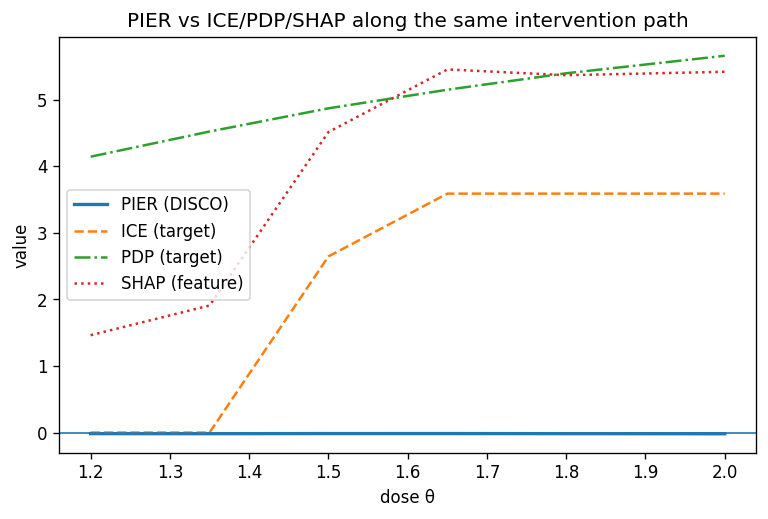

In [9]:

fig, ax = plt.subplots(1, 1, figsize=(7.5, 4.5))
ax.plot(pier_res["thetas"], pier_res["pier"], label="PIER (DISCO)", linewidth=2)
ax.plot(θ, ice_y,  label="ICE (target)", linestyle="--")
ax.plot(θ, pdp_y,  label="PDP (target)", linestyle="-.")
ax.plot(θ, shap_y, label="SHAP (feature)", linestyle=":")
ax.axhline(0, linewidth=1)
ax.set_xlabel("dose θ")
ax.set_ylabel("value")
ax.legend()
ax.set_title("PIER vs ICE/PDP/SHAP along the same intervention path")
plt.show()



**读图建议**  
- 若 **ICE/PDP/SHAP 很大而 PIER 接近 0**：说明这是同伴共享的**共模变化**（单模型“敏感”，但**不是同伴不可表达**的独特性）。  
- 若 **PIER 与 ICE/PDP/SHAP 同向增长**，并随“独特性”增强单调增长：对应论文**可鉴别性**实验的趋势（图 4）。

> 预/后网格拆分与 AUC 定义详见论文 §3.1–§3.2；算法框架见 Algorithm 1。